In [1]:
#PROBLEM STATEMENT: Stock Price Time Series Analysis and Forecasting

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [21]:
df = pd.read_csv('stockmarket.csv')
df.head()

,mic,symbol,isin,date,open_value,high_value,low_value,last_value,change_prev_close_percentage,turnover
0,XZAG,CBX,HRZB00ICBEX6,2015-12-30,1689.22,1689.71,1673.62,1689.63,-0.02,2017520.82
1,XZAG,CBX,HRZB00ICBEX6,2015-12-29,1675.79,1691.02,1673.37,1689.94,0.84,1094356.06
2,XZAG,CBX,HRZB00ICBEX6,2015-12-28,1655.92,1677.17,1652.76,1675.88,1.21,1125687.29
3,XZAG,CBX,HRZB00ICBEX6,2015-12-23,1647.66,1655.77,1641.41,1655.77,0.49,592284.75
4,XZAG,CBX,HRZB00ICBEX6,2015-12-22,1655.71,1655.71,1642.60,1647.67,-0.55,2714509.05


In [22]:
df.info()
print('---------------------------------------------------')
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1498 entries, 0 to 1497
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   mic                           1498 non-null   object 
 1   symbol                        1498 non-null   object 
 2   isin                          1498 non-null   object 
 3   date                          1498 non-null   object 
 4   open_value                    1497 non-null   float64
 5   high_value                    1497 non-null   float64
 6   low_value                     1497 non-null   float64
 7   last_value                    1497 non-null   float64
 8   change_prev_close_percentage  1497 non-null   float64
 9   turnover                      1498 non-null   float64
dtypes: float64(6), object(4)
memory usage: 117.2+ KB
---------------------------------------------------


mic                             0
symbol                          0
isin                            0
date                            0
open_value                      1
high_value                      1
low_value                       1
last_value                      1
change_prev_close_percentage    1
turnover                        0
dtype: int64

In [23]:
df= df.dropna()
df.isnull().sum()

mic                             0
symbol                          0
isin                            0
date                            0
open_value                      0
high_value                      0
low_value                       0
last_value                      0
change_prev_close_percentage    0
turnover                        0
dtype: int64

In [24]:
df['date'] = pd.to_datetime(df['date'])

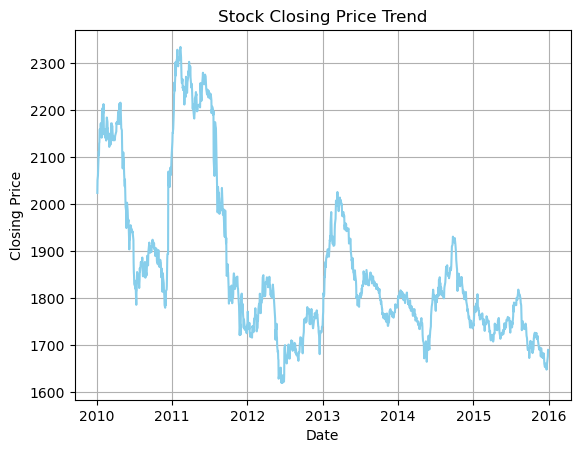

In [25]:
#TREND ANALYSIS
plt.plot(df['date'], df['last_value'], color='skyblue' )

plt.title("Stock Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.grid(True)

plt.show()

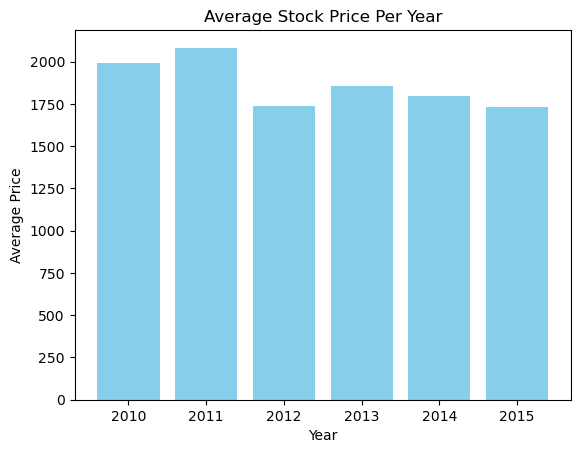

In [27]:
#AVERAGE STOCK PRICE PER YEAR
df['year'] = df['date'].dt.year
yearly_average = df.groupby('year')['last_value'].mean()

plt.bar(yearly_average.index, yearly_average.values, color= 'skyblue')

plt.title("Average Stock Price Per Year")
plt.xlabel("Year")
plt.ylabel("Average Price")

plt.show()

In [28]:
#FUTURE FORECAST USING LINEARREGRESSION
df['Index'] = np.arange(len(df)) #create index for prediction 

In [29]:
X = df[['Index']]
y = df['last_value']

In [30]:
model = LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
#PREDICTING FUTURE VALUES
future_index = pd.DataFrame({'Index': np.arange(len(df), len(df)+30)})
future_values = model.predict(future_index)
print('Future Values: ',future_values)

Future Values:  [2053.77794358 2054.02760966 2054.27727574 2054.52694182 2054.7766079
 2055.02627398 2055.27594006 2055.52560614 2055.77527222 2056.0249383
 2056.27460438 2056.52427046 2056.77393654 2057.02360262 2057.2732687
 2057.52293478 2057.77260086 2058.02226694 2058.27193302 2058.5215991
 2058.77126518 2059.02093127 2059.27059735 2059.52026343 2059.76992951
 2060.01959559 2060.26926167 2060.51892775 2060.76859383 2061.01825991]


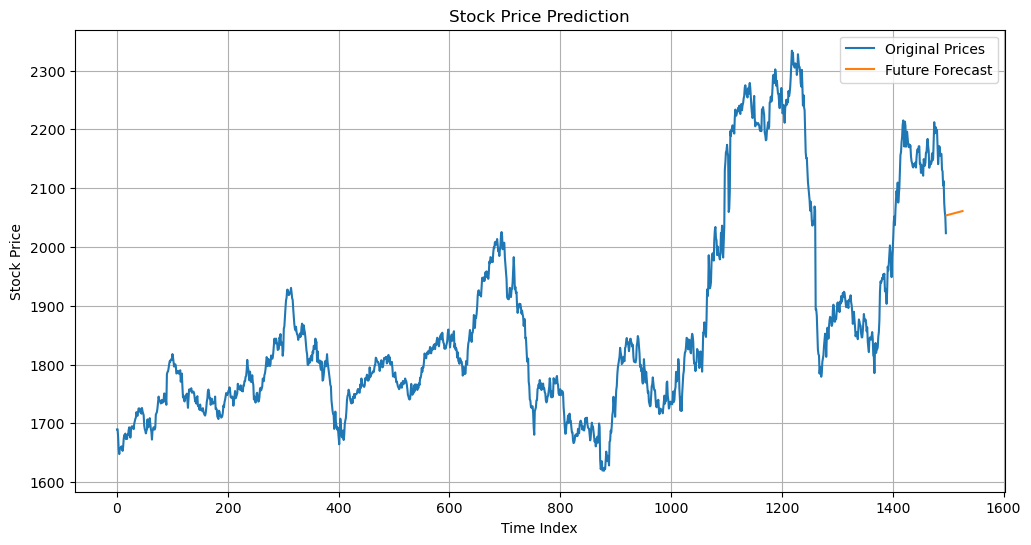

In [32]:
#FORECASTING

plt.figure(figsize=(12,6))

# Original Data
plt.plot( df['Index'], df['last_value'], label='Original Prices')

# Future Prediction
plt.plot( future_index, future_values, label='Future Forecast')

plt.title("Stock Price Prediction")
plt.xlabel("Time Index")
plt.ylabel("Stock Price")

plt.legend()

plt.grid(True)

plt.show()